In [1]:
from aizynthfinder.interfaces import AiZynthApp
from cgr_clustering.aizynth_converter import (
    extract_routes_from_tree, 
    filter_unique_routes
)
from tqdm import tqdm
import pickle

### Routes Generation

In [2]:
smiles = 'N#CC1(c2ccc(NC(=O)c3cccnc3NCc3ccncc3)cc2)CCCC1' 

In [3]:
# Load the AiZynthFinder application
app = AiZynthApp("config.yml")

Loading template-based expansion policy model from ./data/uspto_model.onnx to uspto
Loading templates from ./data/uspto_templates.csv to uspto
Loading template-based expansion policy model from ./data/uspto_ringbreaker_model.onnx to ringbreaker
Loading templates from ./data/uspto_ringbreaker_templates.csv.gz to ringbreaker
Loading filter policy model from ./data/uspto_filter_model.onnx to uspto
Loading stock from InMemoryInchiKeyQuery to askcos


Text(value='', continuous_update=False, description='SMILES')

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

### --- Route Extraction and Filtering ---

In [4]:
route_collections = extract_routes_from_tree(app)
print(f"Extracted {len(route_collections)} route collections.")
filtered_route_collection = filter_unique_routes(route_collections)
print(f"Filtered to {len(filtered_route_collection)} unique routes.")

Extracted 712 route collections.
Filtered to 230 unique routes.


### --- RouteCGR and SB-CGRs ---

In [5]:
from cgr_clustering.aizynth_converter import extract_all_route_cgrs
from synplan.chem.reaction_routes.route_cgr import *

In [6]:
route_cgrs_dict = extract_all_route_cgrs(filtered_route_collection)

230it [00:31,  7.20it/s]


In [7]:
sb_cgrs_dict = compose_all_sb_cgrs(route_cgrs_dict)

### Clustering by SB-CGR

In [8]:
from synplan.chem.reaction_routes.clustering import cluster_routes

sbp_clusters = cluster_routes(sb_cgrs_dict)
print("Number of SB groups:", len(sbp_clusters))

Number of SB groups: 24


In [ ]:
for i, group in sbp_clusters.items():
    print(i)
    sb_cgr = group['sb_cgr']
    sb_cgr.clean2d()
    display(sb_cgr)
    print(group['route_ids'])

### Fixing the mismapping output - SKIP this part if mapping is okay

In [12]:
from cgr_clustering.sb_clustering import *

In [ ]:
sbp_groups_n = remap_final_cgrs(sbp_clusters, smiles)

In [16]:
verbose = True
clean_sbp_groups = map_error_fix(sbp_groups_n, verbose=verbose)
new_clusters = merge_identical_sb_cgr(clean_sbp_groups, verbose=verbose)
ren_clusters = renumber_clusters_by_strat_bonds(new_clusters)

Fixed error clusters: ['3.6', '4.2', '4.4', '5.4']
3.2 4.4 - merged
3.3 4.2 - merged


In [ ]:
for i, group in ren_clusters.items():
    print(i)
    sb_cgr = group['sb_cgr']
    sb_cgr.clean2d()
    display(sb_cgr)
    print(group['strat_bonds'])

In [17]:
len(ren_clusters)

22

### Results overlaping Comparison

In [18]:
from collections import defaultdict

cluster_arr = filtered_route_collection.cluster(len(ren_clusters))
cluster_ab = defaultdict(list)
for idx, val in enumerate(cluster_arr):
    cluster_ab[val+1].append(idx)

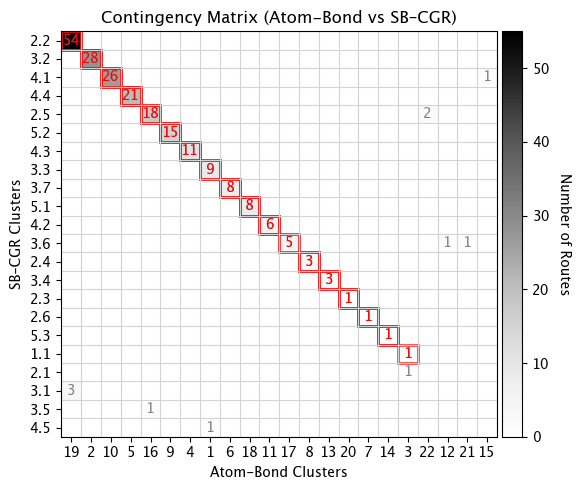

In [ ]:
from cgr_clustering.comparing import *
from cgr_clustering.visualization import display_contingency_matrix

y_true, y_pred = calculate_similarity_metrics(ren_clusters, cluster_ab)
cm = compute_contingency_matrix(y_true, y_pred)
matched, avg_jaccard = match_clusters(ren_clusters, cluster_ab)
cm_sorted, matches = diagonalize_contingency(cm)
display_contingency_matrix(matches, cm_sorted, method='Atom-Bond')

### Explore routes by IDs

Need to run image generetaion (might take a while)

In [20]:
images = filtered_route_collection.make_images()

In [27]:
from cgr_clustering.comparing import contingency_nodes

def show_routes_in_cell(sb_cgr_ind, ted_ind, first_n=10):
    sb_cgr = ren_clusters[sb_cgr_ind]['sb_cgr']
    sb_cgr.clean2d()
    display(sb_cgr)
    routes_list = contingency_nodes(ren_clusters, cluster_ab, sb_cgr_ind, ted_ind) 
    print('Number of routes in cell', len(routes_list))
    print('Routes ids in AiZynthFinder list', routes_list)
    for route in routes_list[:first_n]:
        print('ID:',route)
        # display(route_collections[route].make_images()[0])
        display(images[route])

Number of routes in cell 54
Routes ids in AiZynthFinder list [0, 1, 4, 6, 8, 9, 12, 13, 14, 16, 17, 18, 23, 24, 28, 29, 30, 31, 33, 84, 100, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 127, 128, 129, 130, 131, 132, 133, 138, 139, 140, 141, 142, 143, 144, 145, 146, 150, 151, 152, 153]
ID: 0


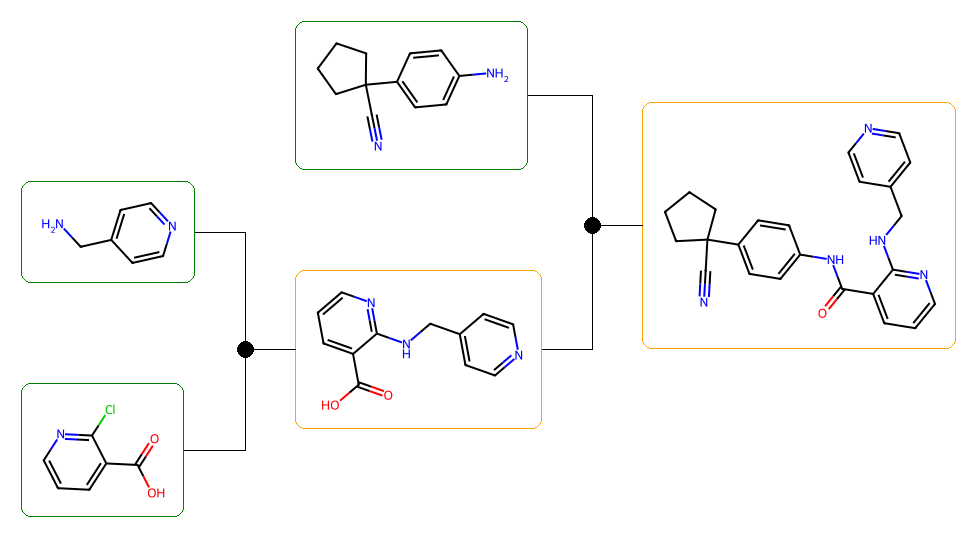

ID: 1


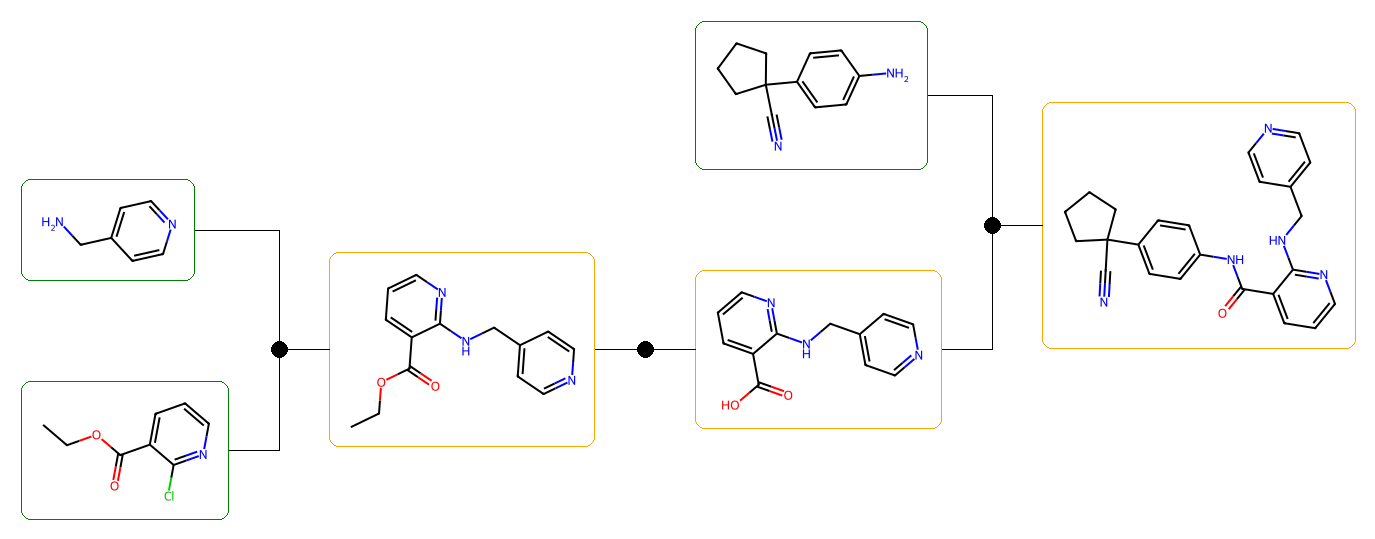

ID: 4


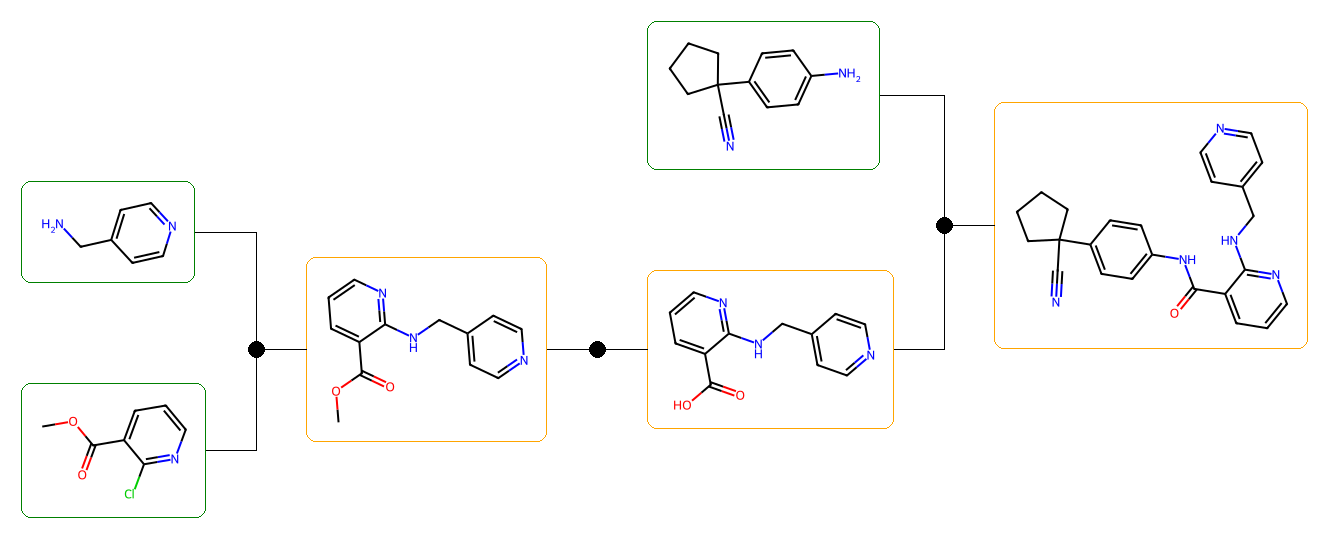

ID: 6


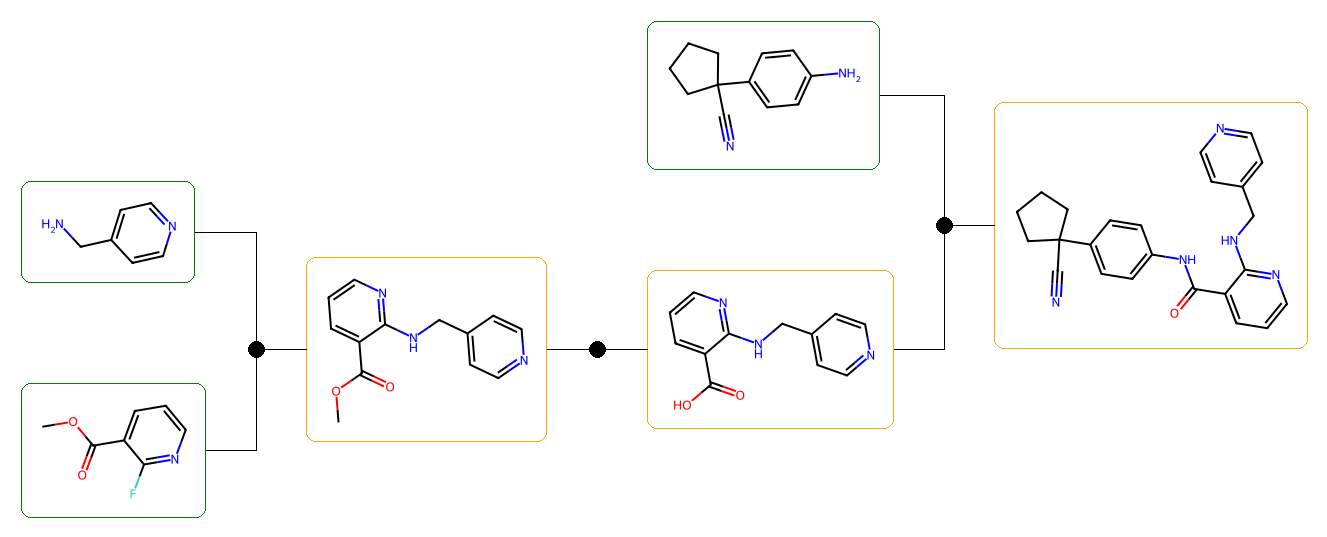

ID: 8


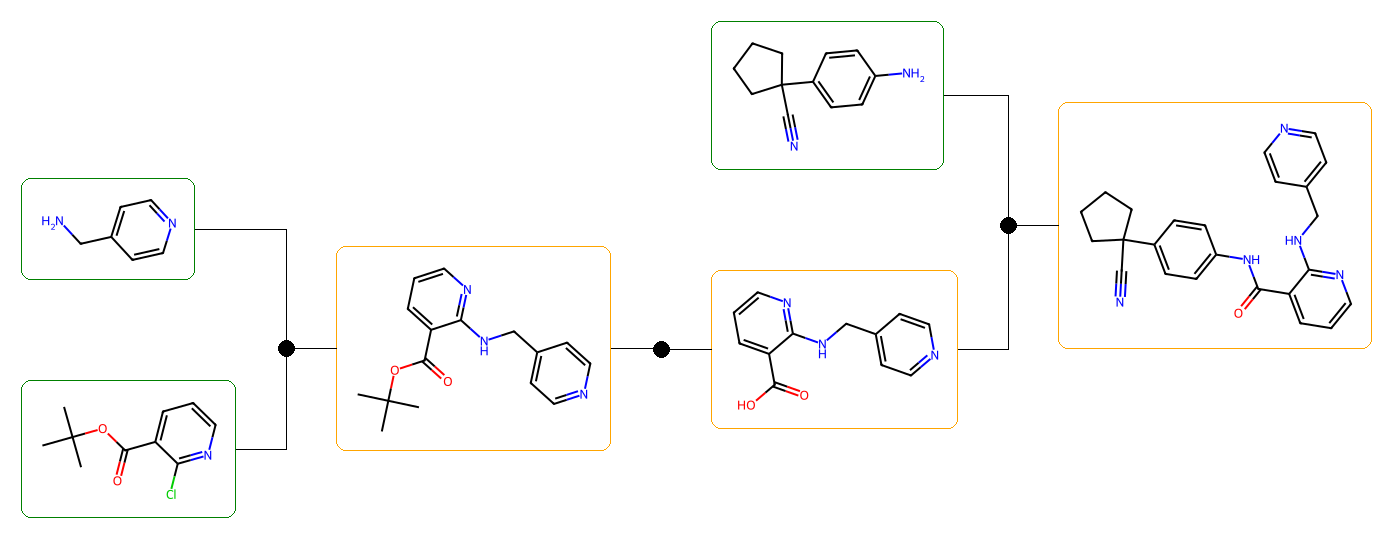

ID: 9


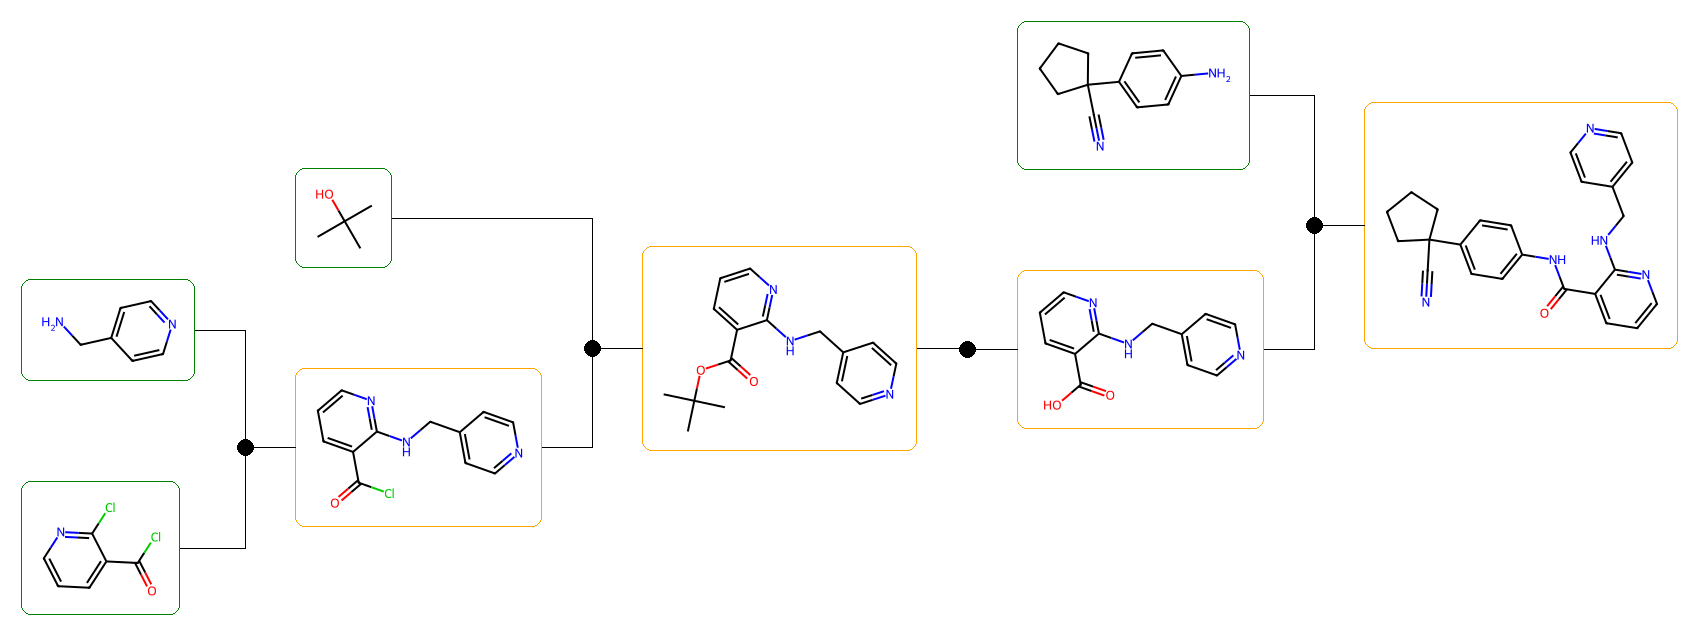

ID: 12


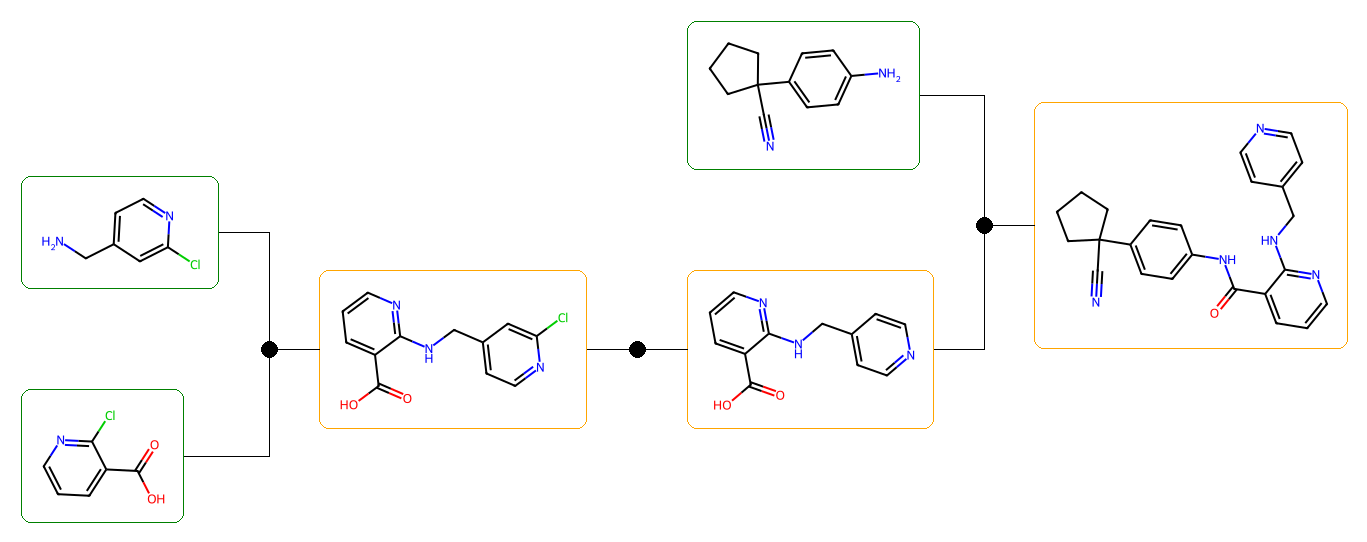

ID: 13


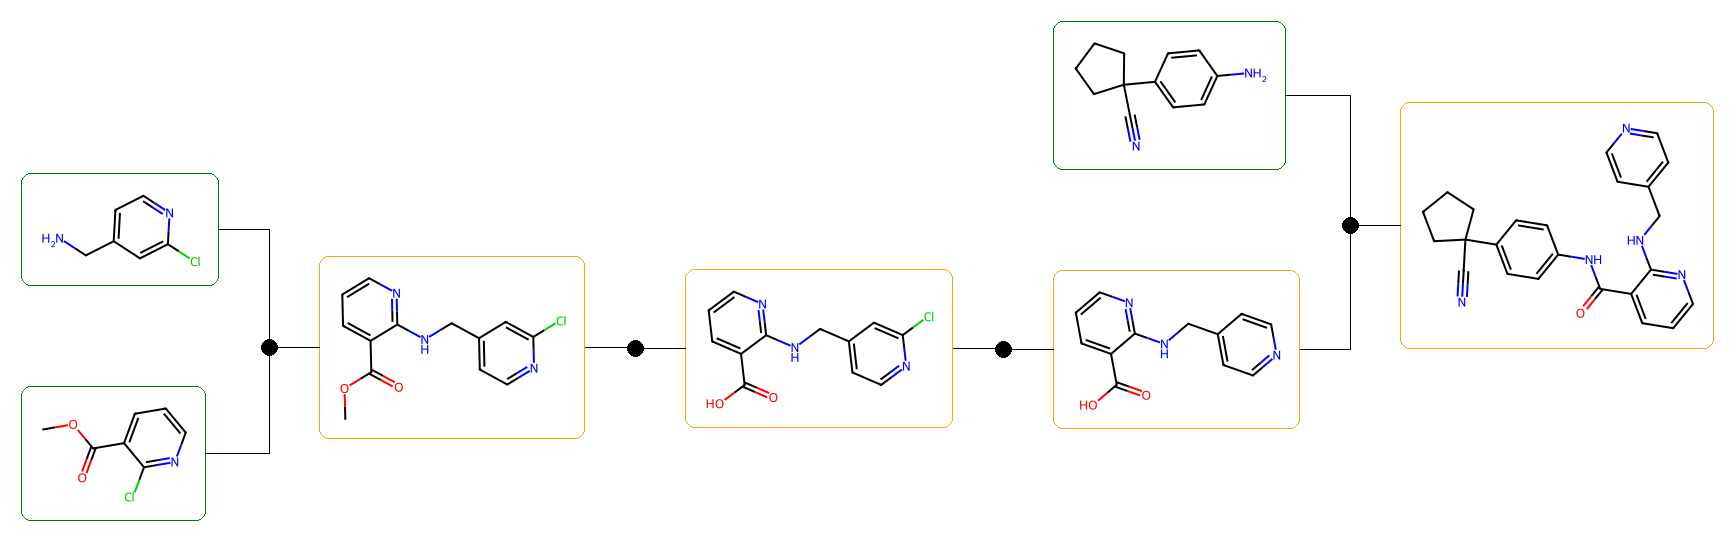

ID: 14


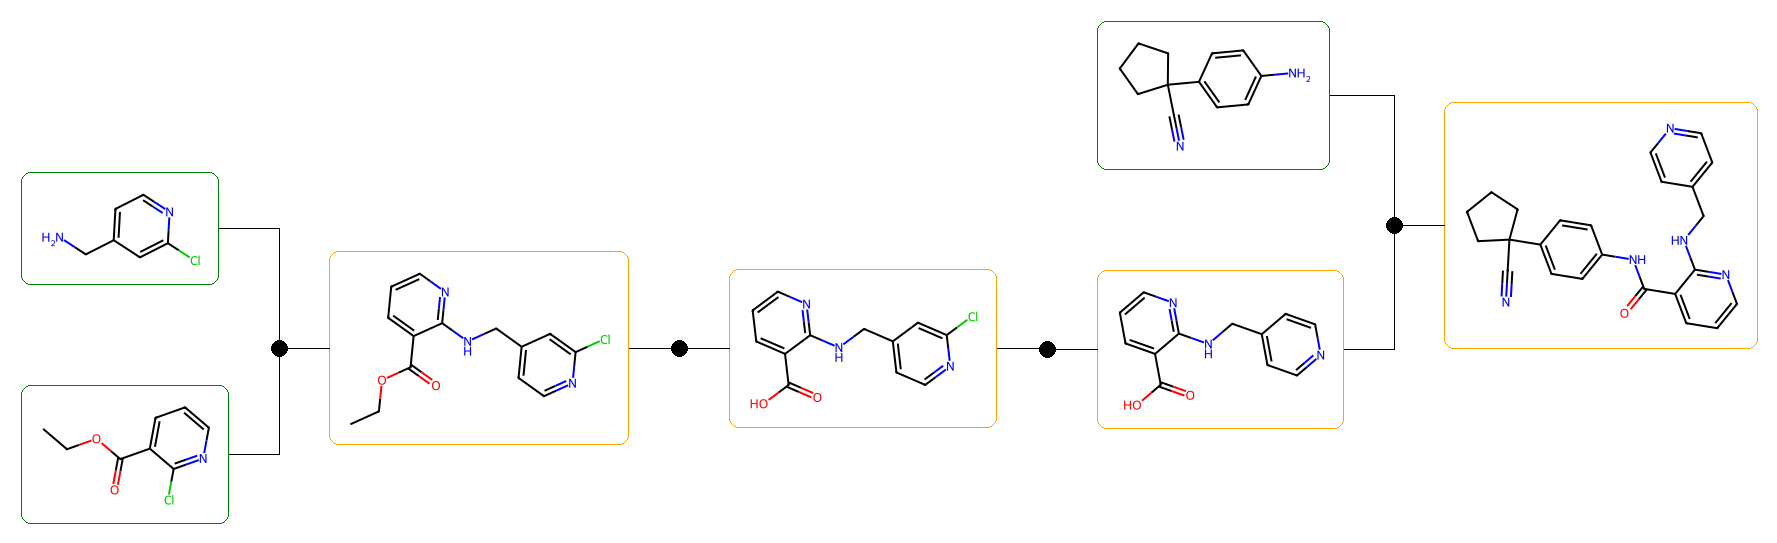

ID: 16


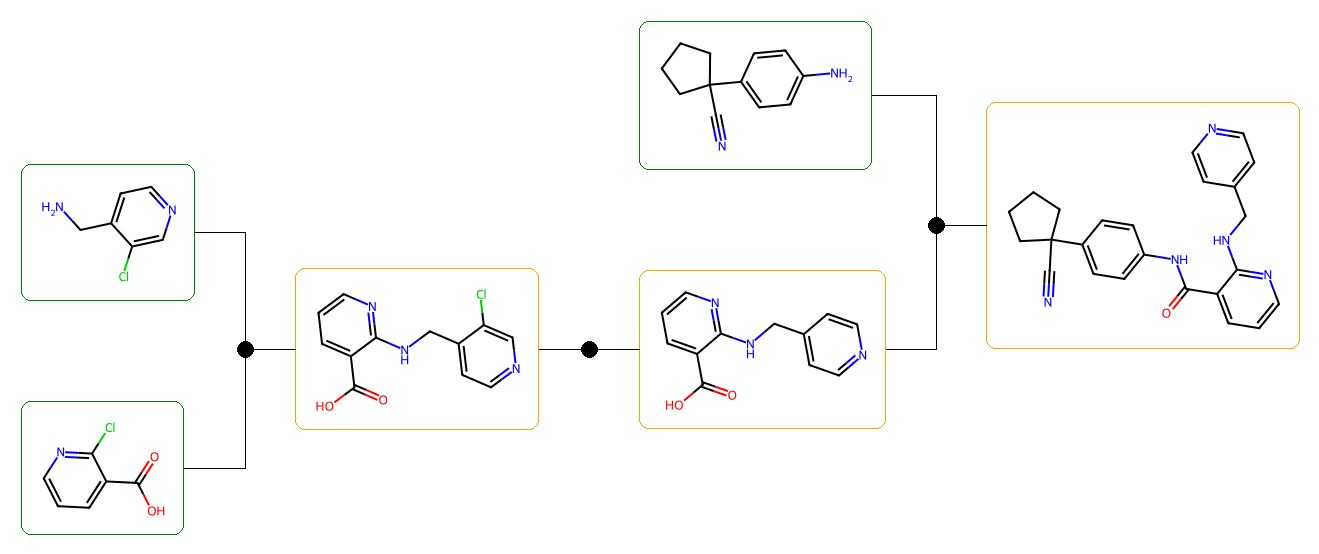

In [28]:
sb_cgr_ind = '2.2'
ted_ind = 19

show_routes_in_cell(sb_cgr_ind, ted_ind, first_n=10)

Number of routes in cell 2
Routes ids in AiZynthFinder list [170, 171]
ID: 170


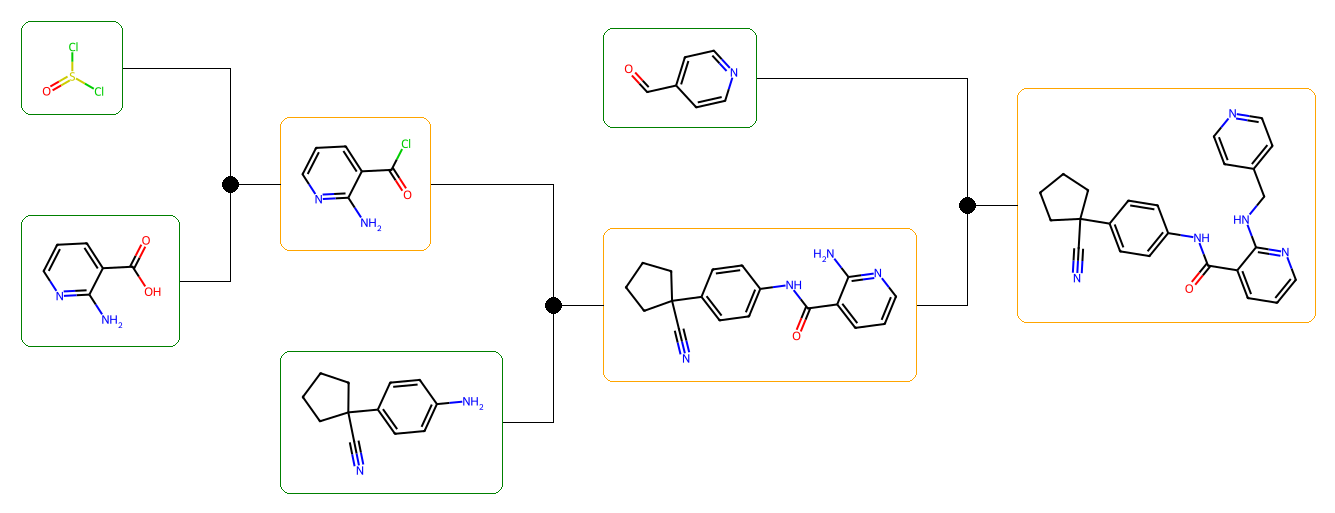

ID: 171


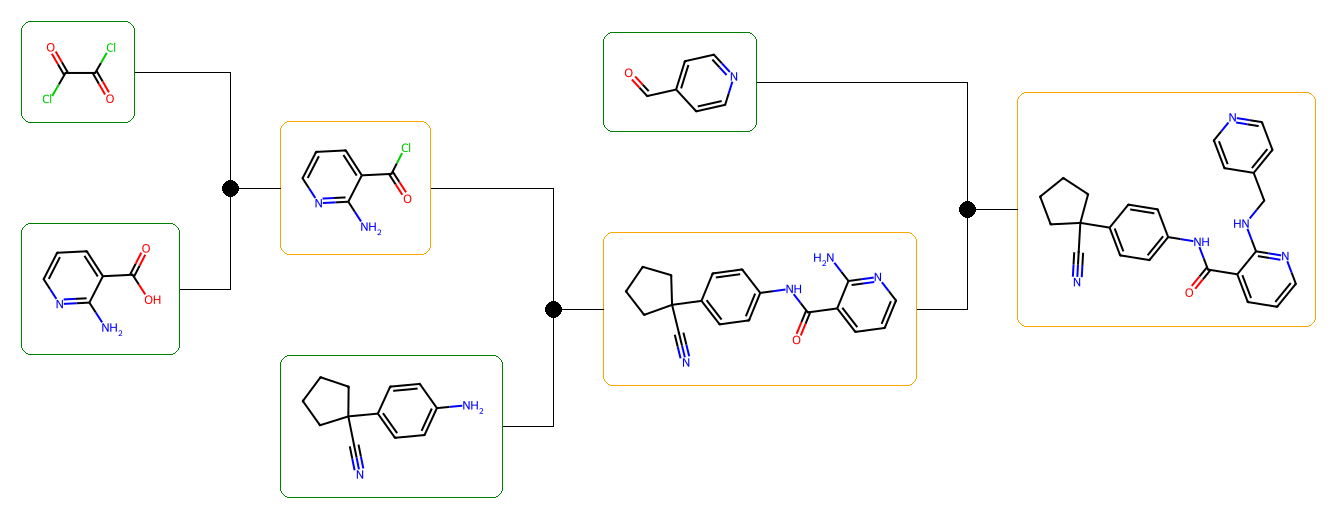

In [29]:
sb_cgr_ind = '2.5'
ted_ind = 22
show_routes_in_cell(sb_cgr_ind, ted_ind)

### For inter-comparison with other retorysnthteic tools' results (SynPlanner and ASKCOS)

In [30]:
pickle.dump(ren_clusters, open('./inter_comp_data/aizynth_clusters.pkl', 'wb'))

In [31]:
ab_dist_matrix = filtered_route_collection.distance_matrix()
ab_dist_matrix

array([[0.        , 0.        , 0.31169379, ..., 0.62424882, 0.58486051,
        0.47123594],
       [0.        , 0.        , 0.30979069, ..., 0.62232825, 0.58248778,
        0.46851363],
       [0.31169379, 0.30979069, 0.        , ..., 0.44670357, 0.38765961,
        0.46402408],
       ...,
       [0.62424882, 0.62232825, 0.44670357, ..., 0.        , 0.15584063,
        0.16422035],
       [0.58486051, 0.58248778, 0.38765961, ..., 0.15584063, 0.        ,
        0.16464632],
       [0.47123594, 0.46851363, 0.46402408, ..., 0.16422035, 0.16464632,
        0.        ]], shape=(230, 230))

In [32]:
from cgr_clustering.utils import distance_matrix
    
sb_cgr_dist_matrix = distance_matrix(sb_cgrs_dict)
sb_cgr_dist_matrix

,0,1,2,3,4,5,6,7,8,9,...,220,221,222,223,224,225,226,227,228,229
0,0.000000,0.000000,0.430380,0.430380,0.000000,0.430380,0.000000,0.430380,0.000000,0.000000,...,0.287671,0.287671,0.287671,0.287671,0.287671,0.287671,0.592179,0.592179,0.592179,0.526316
1,0.000000,0.000000,0.430380,0.430380,0.000000,0.430380,0.000000,0.430380,0.000000,0.000000,...,0.287671,0.287671,0.287671,0.287671,0.287671,0.287671,0.592179,0.592179,0.592179,0.526316
2,0.430380,0.430380,0.000000,0.000000,0.430380,0.000000,0.430380,0.000000,0.430380,0.430380,...,0.592179,0.592179,0.592179,0.592179,0.592179,0.592179,0.283784,0.283784,0.283784,0.556818
3,0.430380,0.430380,0.000000,0.000000,0.430380,0.000000,0.430380,0.000000,0.430380,0.430380,...,0.592179,0.592179,0.592179,0.592179,0.592179,0.592179,0.283784,0.283784,0.283784,0.556818
4,0.000000,0.000000,0.430380,0.430380,0.000000,0.430380,0.000000,0.430380,0.000000,0.000000,...,0.287671,0.287671,0.287671,0.287671,0.287671,0.287671,0.592179,0.592179,0.592179,0.526316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,0.287671,0.287671,0.592179,0.592179,0.287671,0.592179,0.287671,0.592179,0.287671,0.287671,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.419753,0.419753,0.419753,0.315789
226,0.592179,0.592179,0.283784,0.283784,0.592179,0.283784,0.592179,0.283784,0.592179,0.592179,...,0.419753,0.419753,0.419753,0.419753,0.419753,0.419753,0.000000,0.000000,0.000000,0.377358
227,0.592179,0.592179,0.283784,0.283784,0.592179,0.283784,0.592179,0.283784,0.592179,0.592179,...,0.419753,0.419753,0.419753,0.419753,0.419753,0.419753,0.000000,0.000000,0.000000,0.377358
228,0.592179,0.592179,0.283784,0.283784,0.592179,0.283784,0.592179,0.283784,0.592179,0.592179,...,0.419753,0.419753,0.419753,0.419753,0.419753,0.419753,0.000000,0.000000,0.000000,0.377358


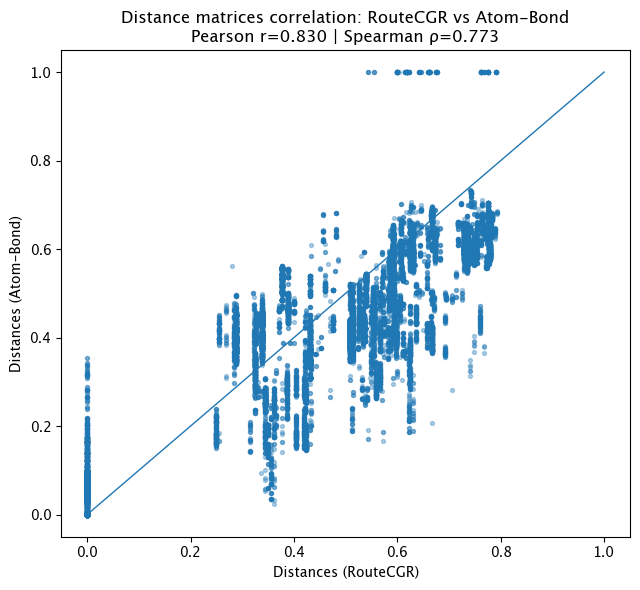

{'pearson_r': 0.8304040132112971, 'spearman_rho': 0.7732659310293594, 'n_pairs': 26335}


In [33]:
from cgr_clustering.visualization import plot_distance_matrix_correlation

stats = plot_distance_matrix_correlation(sb_cgr_dist_matrix, ab_dist_matrix, method_1 = "RouteCGR", method_2 = "Atom-Bond")
print(stats)


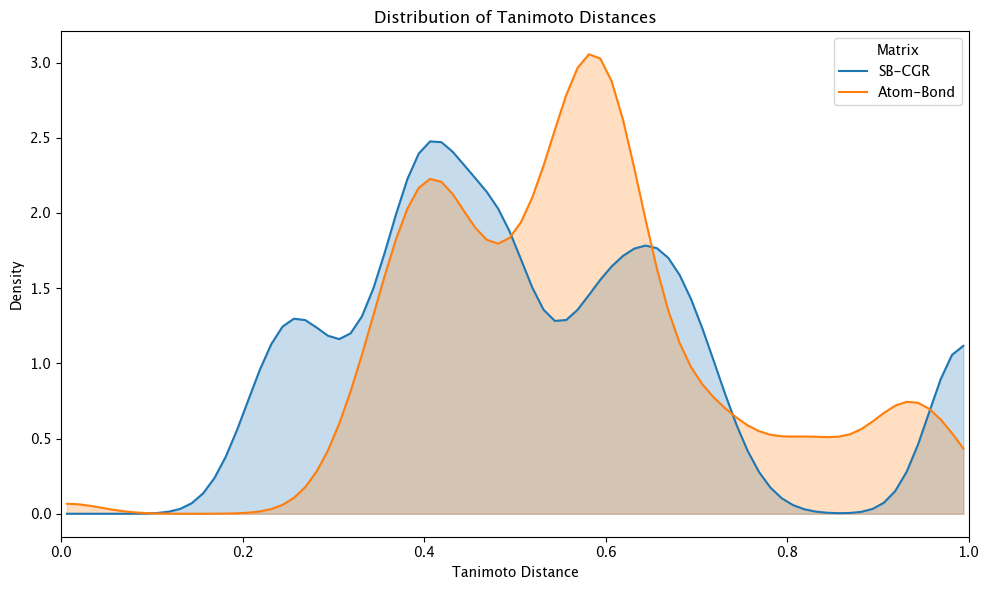

In [34]:
from cgr_clustering.visualization import plot_tanimoto_similarity_distributions
# If you already have similarity matrices:
D_fp = sb_cgr_dist_matrix.values   # from the earlier code (1 - tanimoto) as a numpy array

plot_tanimoto_similarity_distributions(
    1-D_fp, 1-ab_dist_matrix,
    labels=("SB-CGR", "Atom-Bond"),
    input_is_distance=False,
    bins=80,
    smooth_sigma_bins=3.0
)
